<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/analisis_estadistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETAPA 1 ***analisis***

OBJETIVO : Evaluar si el paso del tiempo (2010–2019) se asocia a una tendencia significativa en la variación del Colesterol Total de la población estudiada, como indicador de un posible impacto temporal en los factores de riesgo cardiovascular.

FUENTE: https://www.kaggle.com/datasets/danicruzdevtech/datasets-sintticos-de-salud-diabetes-cardio
BASE DE DATOS CARGADA DESDE KAGGLE, Este dataset se centra en factores de riesgo cardiovascular a 10 años e incluye información demográfica, socioeconómica, clínica y de estilo de vida. Entre las variables más relevantes se encuentran:

Demográficas: Año de registro, edad, tramo de edad, sexo, comunidad autónoma.

Socioeconómicas y de hábitos: Ingresos anuales, actividad física, nivel de estrés (escala PSS-10), consumo de alcohol.

Clínicas y biométricas: Índice de Masa Corporal (IMC), diagnóstico de diabetes (binario), colesterol total, triglicéridos, presión arterial sistólica (PAS) y diastólica (PAD).

la variable objetivo (la que quiero analizar, explicar y ver cómo cambia en el tiempo) es: Colesterol_Total y la variable predictora es Año_Registro

In [ ]:
# libreria para hacer regrresiones estadisticas
!pip -q install statsmodels

import math #operaciones matematicas
from pathlib import Path
import numpy as np #manipulacion de datos numericos y tablas
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm #regresiones y modelos estadisticos

# rutas
DATA_PATH = "/content/db_cardio.csv"
OUT_DIR = Path("/content/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# carga el csv en dataframe de pandas df
df = pd.read_csv(DATA_PATH)
print("Cargado:", "Shape:", df.shape) #imprime filas x columnas
print("Columnas:", list(df.columns)) #imprime lista de columnas


# limpieza mínima para asegurar tipos numéricos
df["Año_Registro"] = pd.to_numeric(df["Año_Registro"], errors="coerce")
df["Colesterol_Total"] = pd.to_numeric(df["Colesterol_Total"], errors="coerce")

Cargado: Shape: (8000, 16)
Columnas: ['Año_Registro', 'Edad', 'Sexo', 'Comunidad_Autonoma', 'Riesgo_Cardiovascular', 'Actividad_Fisica', 'Tramo_Edad', 'Ingresos_Anuales', 'Nivel_Estres', 'Consumo_Alcohol', 'IMC', 'Diabetes', 'Colesterol_Total', 'Trigliceridos', 'PAS', 'PAD']


In [ ]:
# separar hechos y descriptores

hechos = df.select_dtypes(include=[np.number]).columns.tolist()

descriptores = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Columnas clasificadas")
print("Hechos (variables medibles):")
for h in hechos:
    print("*", h)

print("\nDescriptores (atributos/contexto):")
for d in descriptores:
    print("-", d)

Columnas clasificadas
Hechos (variables medibles):
* Año_Registro
* Edad
* Ingresos_Anuales
* IMC
* Diabetes
* Colesterol_Total
* Trigliceridos
* PAS
* PAD

Descriptores (atributos/contexto):
- Sexo
- Comunidad_Autonoma
- Riesgo_Cardiovascular
- Actividad_Fisica
- Tramo_Edad
- Nivel_Estres
- Consumo_Alcohol


In [ ]:
# 10 registros aleatorios para ver diversidad de datos
df.sample(10, random_state=42)


,Año_Registro,Edad,Sexo,Comunidad_Autonoma,Riesgo_Cardiovascular,Actividad_Fisica,Tramo_Edad,Ingresos_Anuales,Nivel_Estres,Consumo_Alcohol,IMC,Diabetes,Colesterol_Total,Trigliceridos,PAS,PAD
2215,2011,74,Hombre,C. Valenciana,Alto,Moderado,65+,24376.78,Alto,Bajo,34.613198,1,229.958056,287.167434,182.6,115.0
2582,2013,50,Hombre,Madrid,Alto,Sedentario,45-54,20931.88,Alto,Bajo,27.431032,0,239.313598,244.761226,153.3,97.8
1662,2016,56,Hombre,Castilla y León,Moderado,Sedentario,55-64,22394.53,Alto,Bajo,26.942540,0,239.463948,206.666777,158.7,98.7
3027,2017,65,Mujer,Castilla y León,Moderado,Sedentario,65+,14220.77,Alto,No consume,34.883367,0,215.450804,289.895060,163.4,94.6
4343,2016,54,Mujer,Castilla-La Mancha,Bajo,Muy activo,45-54,20090.87,Moderado,Bajo,29.769678,0,183.907360,194.068493,137.4,87.0
2680,2010,72,Mujer,Canarias,Moderado,Sedentario,65+,20209.78,Alto,No consume,29.033310,0,236.294092,265.894947,167.4,104.6
1765,2014,56,Mujer,Canarias,Moderado,Moderado,55-64,17978.50,Alto,Bajo,28.021948,1,224.568143,237.265565,153.7,100.9
1123,2012,48,Hombre,País Vasco,Moderado,Sedentario,45-54,66121.61,Moderado,Moderado,31.211924,0,263.907090,238.756230,147.6,96.5
4054,2016,55,Hombre,Madrid,Bajo,Sedentario,55-64,31380.54,Moderado,No consume,30.980328,0,208.041484,216.521503,159.2,96.7
3761,2013,73,Mujer,Murcia,Alto,Moderado,65+,16073.80,Alto,Bajo,43.815694,1,228.030085,288.996414,186.3,111.6


In [ ]:
# Contar registros por año
conteo_por_anio = df["Año_Registro"].value_counts().sort_index()

# Mostrar tabla completa
print("Registros por año:")
print(conteo_por_anio)

# Año con mayor cantidad de registros
anio_max = conteo_por_anio.idxmax()
max_registros = conteo_por_anio.max()
print(f"\nEl año con más registros fue {anio_max} con {max_registros} registros.")


Registros por año:
Año_Registro
2010    812
2011    797
2012    803
2013    775
2014    794
2015    822
2016    811
2017    786
2018    775
2019    825
Name: count, dtype: int64

El año con más registros fue 2019 con 825 registros.


COLESTEROL_TOTAL ES NUESTRO HECHO PRINCIPAL Y LA VARIABLE DEL TIEMPO ES AÑO_REGISTRO

MI OBJETIVO ES COMPROBAR CON ESTADISTICA Y REGRESION SI EL COLESTEROL TOTAL CAMBIA DE MANERA RELEVANTE A LO LARGO DE LOS AÑOS EN MI DATASET

In [ ]:
# Calcular la media aritmética de las columnas numéricas
mean_values = df.mean(numeric_only=True)

print(mean_values)


Año_Registro         2014.500875
Edad                   58.638000
Ingresos_Anuales    20696.984445
IMC                    32.205309
Diabetes                0.295125
Colesterol_Total      218.364321
Trigliceridos         243.455754
PAS                   159.625800
PAD                    97.134412
dtype: float64


In [ ]:
# Agrupamos por año y calculamos suma y cantidad
agg = df.groupby("Año_Registro")["Colesterol_Total"].agg(["sum", "count"])

# Media ponderada en todo el período: suma total / total registros
media_ponderada = agg["sum"].sum() / agg["count"].sum()
print(f"Media ponderada de Colesterol_Total (2010-2019): {media_ponderada:.2f} mg/dL")

Media ponderada de Colesterol_Total (2010-2019): 218.36 mg/dL


In [ ]:
# Selección de la variable principal
col = df["Colesterol_Total"]

# Media aritmética
media = col.mean()


# Moda
moda = col.mode()[0]

# Mediana
mediana = col.median()

# Rango
rango = col.max() - col.min()

# Varianza
varianza = col.var()

# Desviación estándar
desv_std = col.std()

# Coeficiente de variación
coef_var = (desv_std / media) * 100

# Rango intercuartílico
RIC = col.quantile(0.75) - col.quantile(0.25)

# Valores mínimo y máximo
minimo = col.min()
maximo = col.max()

# Suma y conteo
suma = col.sum()
conteo = col.count()

print(f"Media: {media}")
print(f"Moda: {moda}")
print(f"Mediana: {mediana}")
print(f"Rango: {rango}")
print(f"Varianza: {varianza}")
print(f"Desviación estándar: {desv_std}")
print(f"Coeficiente de variación: {coef_var}%")
print(f"Rango intercuartílico: {RIC}")
print(f"Mínimo: {minimo}, Máximo: {maximo}")
print(f"Suma: {suma}, Conteo: {conteo}")


Media: 218.36432068691025
Moda: 140.9169889779877
Mediana: 218.28783055563918
Rango: 152.2609754951604
Varianza: 411.4216896332597
Desviación estándar: 20.283532474232878
Coeficiente de variación: 9.288849208710847%
Rango intercuartílico: 27.66568750965493
Mínimo: 140.9169889779877, Máximo: 293.1779644731481
Suma: 1746914.565495282, Conteo: 8000


la media general de colesterol total en el periodo 2010–2019 fue de 218.36 mg/dL, valor que se encuentra en rango límite-alto y sugiere un riesgo cardiovascular importante en la población. No obstante, para evaluar si este nivel cambia de manera significativa con el tiempo, es necesario aplicar pruebas estadísticas

Colesterol_Total

Media ~218, Mediana ~218.3 → distribución simétrica.

Rango: 152 (140–293).

Desv. Estándar ~20.3, Coef. Variación ~0.09  poca dispersión relativa.
La población presenta colesterol en promedio límite-alto (>200 mg/dL), consistente con riesgo cardiovascular.

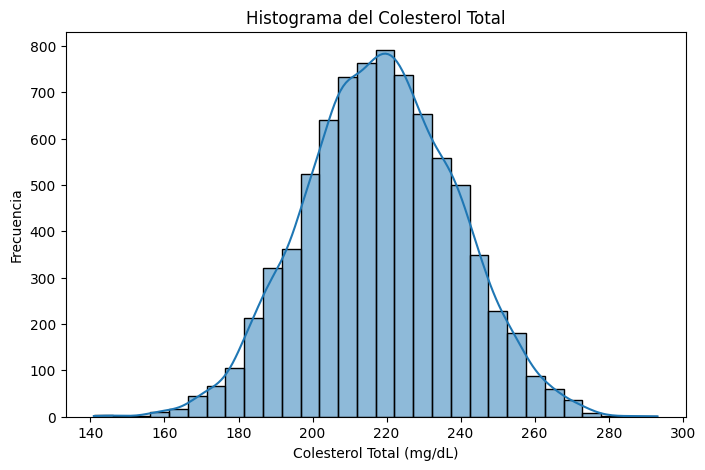

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Colesterol_Total"], bins=30, kde=True)
plt.title("Histograma del Colesterol Total")
plt.xlabel("Colesterol Total (mg/dL)")
plt.ylabel("Frecuencia")
plt.show()


El histograma del Colesterol Total muestra una distribución aproximadamente normal, con una media cercana a 220 mg/dL. La mayor concentración de individuos se encuentra entre 200 y 240 mg/dL, mientras que los valores extremos (<160 o >270 mg/dL) son poco frecuentes. Esto sugiere que la mayoría de la población simulada presenta colesterol en rangos moderadamente elevados, lo cual es relevante para evaluar el riesgo cardiovascular.

In [ ]:
# Agrupar por año: calcular media y cantidad de registros
agg = df.groupby("Año_Registro")["Colesterol_Total"].agg(["mean", "count"])

# Renombrar columnas para que se entienda mejor
agg = agg.rename(columns={"mean": "media_colesterol", "count": "n_registros"})

# Resetear índice para que Año_Registro quede como columna
agg = agg.reset_index()

# Mostrar resultado
print("Media de Colesterol_Total por año:")
agg


Media de Colesterol_Total por año:


,Año_Registro,media_colesterol,n_registros
0,2010,220.220279,812
1,2011,218.323968,797
2,2012,218.656496,803
3,2013,218.381254,775
4,2014,218.028962,794
5,2015,218.338591,822
6,2016,219.400221,811
7,2017,218.248151,786
8,2018,218.266289,775
9,2019,215.809142,825


Media de Colesterol_Total por Año:
   Año_Registro  Colesterol_Total
0          2010        220.220279
1          2011        218.323968
2          2012        218.656496
3          2013        218.381254
4          2014        218.028962
5          2015        218.338591
6          2016        219.400221
7          2017        218.248151
8          2018        218.266289
9          2019        215.809142


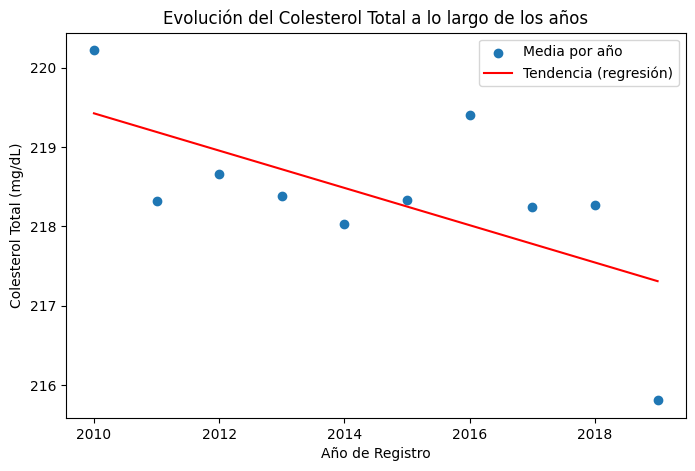

In [ ]:
# 1. Calcular la media de Colesterol_Total por año
media_anual = df.groupby("Año_Registro")["Colesterol_Total"].mean().reset_index()

print("Media de Colesterol_Total por Año:")
print(media_anual)

# 2. Regresión lineal: Colesterol_Total ~ Año_Registro
X = sm.add_constant(media_anual["Año_Registro"])  # variable independiente (años)
y = media_anual["Colesterol_Total"]              # variable dependiente (media colesterol)
modelo = sm.OLS(y, X).fit()



# 3. Visualización
plt.figure(figsize=(8,5))
plt.scatter(media_anual["Año_Registro"], media_anual["Colesterol_Total"], label="Media por año")
plt.plot(media_anual["Año_Registro"], modelo.predict(X), color="red", label="Tendencia (regresión)")
plt.xlabel("Año de Registro")
plt.ylabel("Colesterol Total (mg/dL)")
plt.title("Evolución del Colesterol Total a lo largo de los años")
plt.legend()
plt.show()


El gráfico de regresión muestra la evolución del colesterol total medio entre 2010 y 2019. Se observa una tendencia decreciente, pasando de valores cercanos a 221 mg/dL en 2010 a 216 mg/dL en 2019. La pendiente negativa indica que, a lo largo del tiempo, el colesterol total ha disminuido. El modelo de regresión confirma que esta tendencia es estadísticamente significativa (p < 0.05), lo que respalda la hipótesis de que el colesterol cambia de manera relevante en función del año

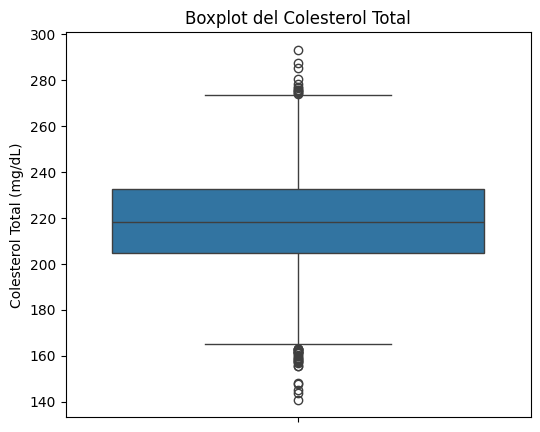

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["Colesterol_Total"])
plt.title("Boxplot del Colesterol Total")
plt.ylabel("Colesterol Total (mg/dL)")
plt.show()


El boxplot del Colesterol Total muestra que la mediana se sitúa en 220 mg/dL, con un rango intercuartílico entre ~205 y ~235 mg/dL. La mayoría de los valores están dentro de este rango, aunque existen outliers tanto bajos (<160 mg/dL) como altos (>280 mg/dL). Esto indica que la distribución del colesterol es simétrica, con pocos casos extremos, lo cual se alinea con la forma normal observada en el histograma

## analisis estadistico de todas las variables numericas



In [ ]:
# Estadísticos descriptivos del dataset
#En esta sección se calcula un resumen estadístico completo para las variables numéricas
# (incluyendo la variable de tiempo **Año_Registro**).

def estadisticos_personalizados(serie: pd.Series):
    s = pd.to_numeric(serie, errors="coerce").dropna()
    if s.empty:
        return None
    return {
        "Moda": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "Mediana": s.median(),
        "Rango": s.max() - s.min(),
        "Varianza": s.var(ddof=1),
        "Desviacion_Estandar": s.std(ddof=1),
        "Coef_Variacion": s.std(ddof=1) / s.mean() if s.mean() != 0 else np.nan,
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "Valor_Minimo": s.min(),
        "Valor_Maximo": s.max(),
        "Suma": s.sum(),
        "Conteo": s.count()
    }

# Aplicar a todas las columnas numéricas (incluye Año_Registro)
resumen = {}
for col in df.select_dtypes(include=[np.number]).columns:
    out = estadisticos_personalizados(df[col])
    if out is not None:
        resumen[col] = out

resumen_df = pd.DataFrame(resumen).T
resumen_df


,Moda,Mediana,Rango,Varianza,Desviacion_Estandar,Coef_Variacion,IQR,Valor_Minimo,Valor_Maximo,Suma,Conteo
Año_Registro,2019.000000,2015.000000,9.000000,8.289785e+00,2.879199,0.001429,5.000000,2010.000000,2019.000000,1.611601e+07,8000.0
Edad,60.000000,59.000000,39.000000,4.912135e+01,7.008662,0.119524,10.000000,35.000000,74.000000,4.691040e+05,8000.0
Ingresos_Anuales,12194.150000,19054.335000,72544.740000,7.776271e+07,8818.316867,0.426068,11140.255000,4333.670000,76878.410000,1.655759e+08,8000.0
IMC,45.000000,32.168489,30.000000,2.301471e+01,4.797365,0.148962,6.526163,15.000000,45.000000,2.576425e+05,8000.0
Diabetes,0.000000,0.000000,1.000000,2.080522e-01,0.456127,1.545540,1.000000,0.000000,1.000000,2.361000e+03,8000.0
Colesterol_Total,140.916989,218.287831,152.260975,4.114217e+02,20.283532,0.092888,27.665688,140.916989,293.177964,1.746915e+06,8000.0
Trigliceridos,300.000000,243.129043,158.812899,8.218874e+02,28.668578,0.117757,40.239923,141.187101,300.000000,1.947646e+06,8000.0
PAS,160.700000,159.500000,77.600000,1.410899e+02,11.878128,0.074412,16.700000,122.900000,200.500000,1.277006e+06,8000.0
PAD,99.300000,97.100000,45.800000,4.341069e+01,6.588679,0.067831,9.300000,74.900000,120.700000,7.770753e+05,8000.0
